# Modelisation

In [2]:
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
pd.set_option('display.max_row', 20)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 500)

In [4]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))

# Import des bases de données

In [5]:
df = pd.read_csv('data.csv', nrows=None)
#df = pd.read_parquet("data.parquet")
df.shape

(356251, 463)

In [6]:
# Conversion des floats 64 → float32
float_cols = df.select_dtypes(include=["float64"]).columns
df[float_cols] = df[float_cols].astype("float32")

# Conversion des int 64 → int32
int_cols = df.select_dtypes(include=["int64"]).columns
df[int_cols] = df[int_cols].astype("int32")

# Conversion des bool → int8 (suffisant et plus léger)
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype("int8")

In [7]:
# File system management
import os
import pickle
import dill

from collections import Counter

# Data manipulation
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.model_selection import cross_val_predict, cross_validate, cross_val_score, train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler

# Hyperparameters optimisation
from hyperopt import tpe, hp, fmin, space_eval, STATUS_OK, Trials, SparkTrials
from hyperopt.pyll.base import scope

# XGBoost
import xgboost as xgb

# LightGBM
import lightgbm as ltb

# Balancing data
from imblearn.over_sampling import SMOTE

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Interpratability

import shap


# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(palette="Set1")

/Users/frabe/.pyenv/versions/3.11.3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
df = df.replace([np.inf, -np.inf], np.nan)

# Split du dataset

In [9]:
df.shape

(356251, 463)

In [10]:
# Define usefull variables
TARGET = 'TARGET'
ID = 'SK_ID_CURR'

In [11]:
# === Split train / test avant tout ===
train_df = df[df['TARGET'].notna()].copy()
test_df  = df[df['TARGET'].isna()].copy()


In [12]:
display(test_df.head())
display(train_df.head())

,Unnamed: 0,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
307507,307507,100001,NaN,1,0,0,0,135000.0,568800.0,20560.5,0.018850,-19241,-2329.0,-5170.0,-812,0,0,1,2.0,2,18,0,0,0,0,...,11.0,1.571429,11.0,36.0,8.857142,62.0,1.0,1.000000,7.0,0.000000,0.000000,0.00000,0.000000,0.00,17397.900391,5885.132324,4.119593e+04,3951.000000,17397.900391,5885.132324,4.119593e+04,-1628.0,-2195.000000,-15365.0,7.0
307508,307508,100005,NaN,0,0,0,0,99000.0,222768.0,17370.0,0.035792,-18064,-4469.0,-9118.0,-1623,0,0,0,2.0,2,9,0,0,0,0,...,1.0,0.111111,1.0,37.0,23.666666,213.0,1.0,1.000000,9.0,0.000000,0.000000,0.00000,0.000000,0.00,17656.244141,6240.205078,5.616184e+04,4813.200195,17656.244141,6240.205078,5.616184e+04,-470.0,-609.555542,-5486.0,9.0
307509,307509,100013,NaN,0,1,0,0,202500.0,663264.0,69777.0,0.019101,-20038,-4458.0,-2175.0,-3503,0,0,0,2.0,2,14,0,0,0,0,...,21.0,0.541936,84.0,38.0,5.722580,887.0,1.0,0.935484,145.0,0.058241,23147.820312,1157.66272,179437.718750,23467724.00,357347.750000,10897.898438,1.689174e+06,6.165000,357347.750000,9740.235352,1.509736e+06,-14.0,-1358.109619,-210507.0,155.0
307510,307510,100028,NaN,1,0,0,2,315000.0,1575000.0,49018.5,0.026392,-13976,-1866.0,-2000.0,-4208,0,1,0,4.0,2,11,0,0,0,0,...,7.0,0.265487,30.0,19.0,3.265487,369.0,1.0,0.911504,103.0,0.045393,8505.000000,622.55072,70348.226562,2972475.75,38988.539062,4979.282227,5.626589e+05,1.170000,38988.539062,4356.731445,4.923107e+05,-29.0,-858.548645,-97016.0,113.0
307511,307511,100038,NaN,0,1,1,1,180000.0,625500.0,32067.0,0.010032,-13040,-2191.0,-4000.0,-4262,1,0,0,3.0,2,5,0,0,0,0,...,0.0,0.000000,0.0,18.0,12.250000,147.0,1.0,1.000000,12.0,0.000000,0.000000,0.00000,0.000000,0.00,11100.599609,11100.337891,1.332040e+05,11097.450195,11100.599609,11100.337891,1.332040e+05,-466.0,-634.250000,-7611.0,12.0


,Unnamed: 0,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
0,0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,0.018801,-9461,-637.0,-3648.0,-2120,0,1,0,1.0,2,10,0,0,0,0,...,0.0,0.000000,0.0,31.0,20.421053,388.0,1.0,1.000000,19.0,0.000000,0.000000,0.000000,0.000000,0.0,53093.746094,11559.247070,2.196257e+05,9251.775391,53093.746094,11559.247070,2.196257e+05,-49.0,-315.421051,-5993.0,19.0
1,1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,0.003541,-16765,-1188.0,-1186.0,-291,0,1,0,2.0,1,11,0,0,0,0,...,0.0,0.000000,0.0,14.0,7.160000,179.0,1.0,1.000000,25.0,0.000000,0.000000,0.000000,0.000000,0.0,560835.375000,64754.585938,1.618865e+06,6662.970215,560835.375000,64754.585938,1.618865e+06,-544.0,-1385.319946,-34633.0,25.0
2,2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,0.010032,-19046,-225.0,-4260.0,-2531,1,1,0,1.0,2,9,0,0,0,0,...,0.0,0.000000,0.0,11.0,7.666667,23.0,1.0,1.000000,3.0,0.000000,0.000000,0.000000,0.000000,0.0,10573.964844,7096.154785,2.128846e+04,5357.250000,10573.964844,7096.154785,2.128846e+04,-727.0,-761.666687,-2285.0,3.0
3,3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,0.008019,-19005,-3039.0,-9833.0,-2437,0,0,0,2.0,2,17,0,0,0,0,...,0.0,0.000000,0.0,77.0,19.375000,310.0,1.0,1.000000,16.0,0.000000,0.000000,0.000000,0.000000,0.0,691786.875000,62947.089844,1.007153e+06,2482.919922,691786.875000,62947.089844,1.007153e+06,-12.0,-271.625000,-4346.0,16.0
4,4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,0.028663,-19932,-3038.0,-4311.0,-3458,0,0,0,1.0,2,11,0,0,0,0,...,12.0,0.954545,63.0,31.0,4.590909,303.0,1.0,0.954545,63.0,0.043995,22655.654297,452.384308,29857.365234,8084830.0,22678.785156,12666.444336,8.359853e+05,0.180000,22678.785156,12214.060547,8.061280e+05,-14.0,-1032.242432,-68128.0,66.0


In [13]:
# variables
TARGET = 'TARGET'
ID = 'SK_ID_CURR'

In [14]:
test_df = test_df.drop(columns=['Unnamed: 0'])
train_df= train_df.drop(columns=['Unnamed: 0'])

In [15]:
display(test_df.shape)
display(train_df.shape)

display(test_df.head())
display(train_df.head())

(48744, 462)

(307507, 462)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
307507,100001,NaN,1,0,0,0,135000.0,568800.0,20560.5,0.018850,-19241,-2329.0,-5170.0,-812,0,0,1,2.0,2,18,0,0,0,0,0,...,11.0,1.571429,11.0,36.0,8.857142,62.0,1.0,1.000000,7.0,0.000000,0.000000,0.00000,0.000000,0.00,17397.900391,5885.132324,4.119593e+04,3951.000000,17397.900391,5885.132324,4.119593e+04,-1628.0,-2195.000000,-15365.0,7.0
307508,100005,NaN,0,0,0,0,99000.0,222768.0,17370.0,0.035792,-18064,-4469.0,-9118.0,-1623,0,0,0,2.0,2,9,0,0,0,0,0,...,1.0,0.111111,1.0,37.0,23.666666,213.0,1.0,1.000000,9.0,0.000000,0.000000,0.00000,0.000000,0.00,17656.244141,6240.205078,5.616184e+04,4813.200195,17656.244141,6240.205078,5.616184e+04,-470.0,-609.555542,-5486.0,9.0
307509,100013,NaN,0,1,0,0,202500.0,663264.0,69777.0,0.019101,-20038,-4458.0,-2175.0,-3503,0,0,0,2.0,2,14,0,0,0,0,0,...,21.0,0.541936,84.0,38.0,5.722580,887.0,1.0,0.935484,145.0,0.058241,23147.820312,1157.66272,179437.718750,23467724.00,357347.750000,10897.898438,1.689174e+06,6.165000,357347.750000,9740.235352,1.509736e+06,-14.0,-1358.109619,-210507.0,155.0
307510,100028,NaN,1,0,0,2,315000.0,1575000.0,49018.5,0.026392,-13976,-1866.0,-2000.0,-4208,0,1,0,4.0,2,11,0,0,0,0,0,...,7.0,0.265487,30.0,19.0,3.265487,369.0,1.0,0.911504,103.0,0.045393,8505.000000,622.55072,70348.226562,2972475.75,38988.539062,4979.282227,5.626589e+05,1.170000,38988.539062,4356.731445,4.923107e+05,-29.0,-858.548645,-97016.0,113.0
307511,100038,NaN,0,1,1,1,180000.0,625500.0,32067.0,0.010032,-13040,-2191.0,-4000.0,-4262,1,0,0,3.0,2,5,0,0,0,0,1,...,0.0,0.000000,0.0,18.0,12.250000,147.0,1.0,1.000000,12.0,0.000000,0.000000,0.00000,0.000000,0.00,11100.599609,11100.337891,1.332040e+05,11097.450195,11100.599609,11100.337891,1.332040e+05,-466.0,-634.250000,-7611.0,12.0


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,0.018801,-9461,-637.0,-3648.0,-2120,0,1,0,1.0,2,10,0,0,0,0,0,...,0.0,0.000000,0.0,31.0,20.421053,388.0,1.0,1.000000,19.0,0.000000,0.000000,0.000000,0.000000,0.0,53093.746094,11559.247070,2.196257e+05,9251.775391,53093.746094,11559.247070,2.196257e+05,-49.0,-315.421051,-5993.0,19.0
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,0.003541,-16765,-1188.0,-1186.0,-291,0,1,0,2.0,1,11,0,0,0,0,0,...,0.0,0.000000,0.0,14.0,7.160000,179.0,1.0,1.000000,25.0,0.000000,0.000000,0.000000,0.000000,0.0,560835.375000,64754.585938,1.618865e+06,6662.970215,560835.375000,64754.585938,1.618865e+06,-544.0,-1385.319946,-34633.0,25.0
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,0.010032,-19046,-225.0,-4260.0,-2531,1,1,0,1.0,2,9,0,0,0,0,0,...,0.0,0.000000,0.0,11.0,7.666667,23.0,1.0,1.000000,3.0,0.000000,0.000000,0.000000,0.000000,0.0,10573.964844,7096.154785,2.128846e+04,5357.250000,10573.964844,7096.154785,2.128846e+04,-727.0,-761.666687,-2285.0,3.0
3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,0.008019,-19005,-3039.0,-9833.0,-2437,0,0,0,2.0,2,17,0,0,0,0,0,...,0.0,0.000000,0.0,77.0,19.375000,310.0,1.0,1.000000,16.0,0.000000,0.000000,0.000000,0.000000,0.0,691786.875000,62947.089844,1.007153e+06,2482.919922,691786.875000,62947.089844,1.007153e+06,-12.0,-271.625000,-4346.0,16.0
4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,0.028663,-19932,-3038.0,-4311.0,-3458,0,0,0,1.0,2,11,0,0,0,0,1,...,12.0,0.954545,63.0,31.0,4.590909,303.0,1.0,0.954545,63.0,0.043995,22655.654297,452.384308,29857.365234,8084830.0,22678.785156,12666.444336,8.359853e+05,0.180000,22678.785156,12214.060547,8.061280e+05,-14.0,-1032.242432,-68128.0,66.0


# Split feature target

In [42]:
X = train_df.drop(columns=[ID, TARGET])
y = train_df[TARGET].astype(int)

X_test = test_df.drop(columns=[TARGET], errors="ignore")

**Split interne**

In [17]:
#Split interne
from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 1_ Baseline (Sans équilibrage de données)

In [18]:

#  Etape1:  Modèle baseline sans équilibrage
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        random_state=42
    ))
])

# Étape 2: Entraînement et prédictions
baseline_model.fit(X_tr, y_tr)

# prédictions
proba_va = baseline_model.predict_proba(X_va)[:, 1]  # probas classe 1
y_pred_05 = (proba_va >= 0.5).astype(int)            # seuil 0.5

# Étape 3  : Évaluation
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, classification_report,
    confusion_matrix
)

print("ROC-AUC :", roc_auc_score(y_va, proba_va))
print("PR-AUC  :", average_precision_score(y_va, proba_va))
print("Accuracy:", accuracy_score(y_va, y_pred_05))
print("F1      :", f1_score(y_va, y_pred_05))
print("\n=== Classification report (0.5) ===")
print(classification_report(y_va, y_pred_05, digits=3))
print("Confusion matrix (0.5):\n", confusion_matrix(y_va, y_pred_05))


ROC-AUC : 0.7687441964455328
PR-AUC  : 0.24921424783381207
Accuracy: 0.9192546583850931
F1      : 0.04756425009589567

=== Classification report (0.5) ===
              precision    recall  f1-score   support

           0      0.921     0.998     0.958     56537
           1      0.498     0.025     0.048      4965

    accuracy                          0.919     61502
   macro avg      0.709     0.511     0.503     61502
weighted avg      0.887     0.919     0.884     61502

Confusion matrix (0.5):
 [[56412   125]
 [ 4841   124]]


ROC-AUC	0.77 : Assez correct — le modèle sépare un peu les bons/mauvais clients, mais ce n’est pas encore suffisant.
PR-AUC	0.25 : Faible — le modèle ne repère pas bien les mauvais payeurs (classe 1), car le jeu est très déséquilibré.
Accuracy	0.92	Trompeuse ici, car 92 % des gens ne font pas défaut → le modèle prédit presque toujours “0”.
F1	0.048	Très faible → confirme que la classe 1 est très mal détectée.

# 2 _ Equilibrage de données

In [19]:

# pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate

from imblearn.pipeline import Pipeline as ImbPipeline


In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, make_scorer

COST_FN = 10.0  # coût FN
COST_FP = 1.0   # coût FP

def min_business_cost(y_true, y_proba, cost_fn=COST_FN, cost_fp=COST_FP):
    """
    Retourne le coût métier minimal (plus petit = mieux)
    en optimisant le seuil à partir des probabilités.

    y_proba : soit vecteur (n_samples,), soit matrice (n_samples, 2) de predict_proba
    """
    y_proba = np.asarray(y_proba)

    # Si on reçoit un tableau (n, 2) => proba de la classe positive = colonne 1
    if y_proba.ndim == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba

    # Seuils candidats = valeurs uniques des scores prédits
    thresholds = np.unique(y_score)

    best_cost = np.inf

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        cost = (cost_fp * fp + cost_fn * fn) / len(y_true)
        if cost < best_cost:
            best_cost = cost

    return float(best_cost)


In [21]:
business_cost_scorer = make_scorer(
    min_business_cost,
    response_method="predict_proba",  # on veut les probas
    greater_is_better=False           # on MINIMISE le coût
)


In [22]:

# Paramètres de base
logreg_params = {"max_iter": 2000, "solver": "lbfgs", "random_state": 42}

# CV légère pour RAM
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# Définition des métriques de scoring

scoring = {
    "roc_auc":   "roc_auc",
    "pr_auc":    "average_precision",
    "accuracy":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, average="binary", zero_division=0),
    "recall":    make_scorer(recall_score, average="binary", zero_division=0),
    "f1":        make_scorer(f1_score, average="binary", zero_division=0),
    "biz_cost":  business_cost_scorer,   # Ajout du score métier
}


# Fonction d’évaluation cross-val
def cv_table(model, X, y):
    out = cross_validate(
        model, X, y, cv=cv, scoring=scoring,
        n_jobs=1,
        error_score="raise",
        return_train_score=False
    )
    rows = []
    for k, v in out.items():
        if k.startswith("test_"):
            metric = k.replace("test_", "")

            # Pour biz_cost, sklearn a mis un signe -, on le remet dans le bon sens
            if metric == "biz_cost":
                v = -v   # on repasse au coût positif

            rows.append({
                "metric": metric,
                "mean": float(np.mean(v)),
                "std":  float(np.std(v))
            })
    rep = pd.DataFrame(rows).set_index("metric").sort_index()

    return rep

In [23]:
def find_best_threshold(y_true, y_proba, cost_fn=COST_FN, cost_fp=COST_FP):
    y_proba = np.asarray(y_proba)
    if y_proba.ndim == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba

    thresholds = np.unique(y_score)

    best_cost = np.inf
    best_t = None

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        cost = (cost_fp * fp + cost_fn * fn) / len(y_true)
        if cost < best_cost:
            best_cost = cost
            best_t = t

    return float(best_cost), float(best_t)

**1) LogReg avec class_weight="balanced"**

In [24]:
pipe_weight_logreg = ImbPipeline(steps=[

    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("clf",   LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

rep_weight = cv_table(pipe_weight_logreg, X_tr, y_tr)
print("\n=== LogReg_weight ===")
print(rep_weight.sort_values("mean", ascending=False))



=== LogReg_weight ===
               mean       std
metric                       
roc_auc    0.766531  0.002613
accuracy   0.702181  0.000592
recall     0.695720  0.005059
biz_cost   0.514294  0.003344
f1         0.273875  0.001341
pr_auc     0.239578  0.004479
precision  0.170496  0.000751


**2) LogReg + SMOTE (oversampling)**

In [25]:
pipe_over_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("over",  SMOTE(sampling_strategy=0.5, random_state=42)),
    ("clf",   LogisticRegression(**logreg_params))
])

rep_over = cv_table(pipe_over_logreg, X_tr, y_tr)
print("\n=== LogReg_SMOTE ===")
print(rep_over.sort_values("mean", ascending=False))



=== LogReg_SMOTE ===
               mean       std
metric                       
accuracy   0.831914  0.000471
roc_auc    0.751856  0.001719
biz_cost   0.535883  0.004057
recall     0.441339  0.004572
f1         0.297716  0.001661
pr_auc     0.227933  0.005378
precision  0.224624  0.000747


**3) LogReg + undersampling**

In [26]:
pipe_under_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("under", RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ("clf",   LogisticRegression(**logreg_params))
])

rep_under = cv_table(pipe_under_logreg, X_tr, y_tr)
print("\n=== LogReg_Under ===")
print(rep_under.sort_values("mean", ascending=False))


=== LogReg_Under ===
               mean       std
metric                       
accuracy   0.839101  0.001152
roc_auc    0.765057  0.002924
biz_cost   0.517221  0.004444
recall     0.447986  0.006825
f1         0.310118  0.002998
precision  0.237151  0.002010
pr_auc     0.237106  0.004580


**4LogReg + SMOTE puis undersampling**

In [27]:
pipe_smote_under_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("over",  SMOTE(sampling_strategy=0.5, random_state=42)),
    ("under", RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
    ("clf",   LogisticRegression(max_iter=2000, random_state=42))
])

rep_smote_under = cv_table(pipe_smote_under_logreg, X_tr, y_tr)
print("\n=== LogReg_SMOTE_Under ===")
print(rep_smote_under.sort_values("mean", ascending=False))


=== LogReg_SMOTE_Under ===
               mean       std
metric                       
roc_auc    0.752727  0.001786
accuracy   0.709006  0.001422
recall     0.662890  0.005047
biz_cost   0.535310  0.004714
f1         0.268908  0.002442
pr_auc     0.226839  0.005152
precision  0.168664  0.001596


In [28]:
# comparaison
comparatif = []
if 'rep_weight' in globals():      comparatif.append(("LogReg_weight", rep_weight))
if 'rep_over' in globals():        comparatif.append(("LogReg_SMOTE", rep_over))
if 'rep_under' in globals():       comparatif.append(("LogReg_Under", rep_under))
if 'rep_smote_under' in globals(): comparatif.append(("LogReg_SMOTE_Under", rep_smote_under))


if comparatif:
    table = pd.concat(
        {name: rep['mean'] for name, rep in comparatif},
        axis=1
    )
    print("\n=== Comparatif (moyennes CV) ===")
    display(table.sort_values(by=table.columns[0], ascending=False))


=== Comparatif (moyennes CV) ===


,LogReg_weight,LogReg_SMOTE,LogReg_Under,LogReg_SMOTE_Under
metric,,,,
roc_auc,0.766531,0.751856,0.765057,0.752727
accuracy,0.702181,0.831914,0.839101,0.709006
recall,0.695720,0.441339,0.447986,0.662890
biz_cost,0.514294,0.535883,0.517221,0.535310
f1,0.273875,0.297716,0.310118,0.268908
pr_auc,0.239578,0.227933,0.237106,0.226839
precision,0.170496,0.224624,0.237151,0.168664


Le modèle LogReg_weight présente le meilleur score métier (coût le plus faible), la meilleure capacité à identifier les défauts (recall le plus élevé) et le meilleur AUC.
Ces trois critères étant essentiels dans ce contexte de risque de crédit avec coût FN 10× supérieur au FP, LogReg_weight est sélectionné comme modèle optimal.

le meilleur modele est celui qui minimise le score business metier.Le meilleur modèle est donc **LogReg_weight** , Recherchons le
 best_t

In [30]:
# =========================
# MLflow : config de base
# =========================
import mlflow

mlflow.set_experiment("credit_risk_logreg_weight")

with mlflow.start_run(run_name="logreg_weight_with_threshold_and_shap"):

    # ---- Log des paramètres principaux
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("cost_fn", COST_FN)
    mlflow.log_param("cost_fp", COST_FP)
    mlflow.log_param("n_splits_cv", cv.n_splits)

2025/11/16 16:34:29 INFO mlflow.tracking.fluent: Experiment with name 'credit_risk_logreg_weight' does not exist. Creating a new experiment.


In [32]:
models = {
    "LogReg_weight": rep_weight,
    "LogReg_Over": rep_over,
    "LogReg_Under": rep_under,
    "LogReg_SMOTE_Under": rep_smote_under
}

with mlflow.start_run(run_name="comparaison_models"):
    for name, rep_cv in models.items():
        for metric_name, row in rep_cv.iterrows():
            mlflow.log_metric(f"{name}_cv_{metric_name}_mean", row["mean"])
            mlflow.log_metric(f"{name}_cv_{metric_name}_std",  row["std"])

In [33]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("credit_risk_final_model")

# Démarrage du run spécifique au modèle final
run = mlflow.start_run(run_name="logreg_weight_final")

print("Run MLflow démarré :", run.info.run_id)

# Log de quelques paramètres globaux
mlflow.log_param("model_name", "LogReg_weight")
mlflow.log_param("model_type", "LogisticRegression")
mlflow.log_param("class_weight", "balanced")
mlflow.log_param("COST_FN", COST_FN)
mlflow.log_param("COST_FP", COST_FP)
mlflow.log_param("n_features", X.shape[1])


2025/11/16 16:59:56 INFO mlflow.tracking.fluent: Experiment with name 'credit_risk_final_model' does not exist. Creating a new experiment.


Run MLflow démarré : e2fedff1edd34c0686db8f0c86ae9c49


460

# Recherche du Best_t

In [34]:
best_model = pipe_weight_logreg   # modèle sélectionné

Trouvons le meilleur seuil métier sur X_va

In [38]:
from sklearn.base import clone

# ============================================================
# 5. Entraînement sur X_tr + recherche du seuil métier sur X_va
# ============================================================

# On entraîne un modèle propre sur X_tr
model_for_threshold = clone(best_model)
model_for_threshold.fit(X_tr, y_tr)

# Probabilités sur X_va
proba_va = model_for_threshold.predict_proba(X_va)[:, 1]

# Seuil métier optimal sur X_va
best_cost_va, best_t = find_best_threshold(y_va, proba_va)
print(f"\nSeuil métier optimal (validation) = {best_t:.4f}")
print(f"Coût métier minimal sur X_va      = {best_cost_va:.4f}")

# Log dans MLflow
mlflow.log_metric("val_best_threshold", best_t)
mlflow.log_metric("val_best_biz_cost", best_cost_va)

# ================
#  Métriques "test"
# ================

# Prédictions binaires avec le seuil métier
y_pred_va = (proba_va >= best_t).astype(int)

# Métriques basées sur les probabilités
auc_test = roc_auc_score(y_va, proba_va)
pr_auc_test = average_precision_score(y_va, proba_va)

# Métriques basées sur les classes
acc_test = accuracy_score(y_va, y_pred_va)
recall_test = recall_score(y_va, y_pred_va)
precision_test = precision_score(y_va, y_pred_va)
f1_test = f1_score(y_va, y_pred_va)

tn, fp, fn, tp = confusion_matrix(y_va, y_pred_va).ravel()
biz_cost_test = (COST_FP * fp + COST_FN * fn) / len(y_va)

print("\n=== Performance finale sur TEST ===")
print(f"Seuil métier utilisé   : {best_t:.4f}")
print(f"Coût métier (test)     : {biz_cost_test:.4f}")
print(f"ROC-AUC                : {auc_test:.4f}")
print(f"Accuracy               : {acc_test:.4f}")
print(f"Recall (classe 1)      : {recall_test:.4f}")
print(f"Precision (classe 1)   : {precision_test:.4f}")
print(f"F1                     : {f1_test:.4f}")
print(f"PR-AUC                 : {pr_auc_test:.4f}")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Log des métriques dans MLflow
mlflow.log_metric("test_biz_cost", biz_cost_test)
mlflow.log_metric("test_roc_auc", auc_test)
mlflow.log_metric("test_accuracy", acc_test)
mlflow.log_metric("test_recall", recall_test)
mlflow.log_metric("test_precision", precision_test)
mlflow.log_metric("test_f1", f1_test)
mlflow.log_metric("test_pr_auc", pr_auc_test)

mlflow.log_metric("test_TN", int(tn))
mlflow.log_metric("test_FP", int(fp))
mlflow.log_metric("test_FN", int(fn))
mlflow.log_metric("test_TP", int(tp))


Seuil métier optimal (validation) = 0.5340
Coût métier minimal sur X_va      = 0.5092

=== Performance finale sur TEST ===
Seuil métier utilisé   : 0.5340
Coût métier (test)     : 0.5092
ROC-AUC                : 0.7687
Accuracy               : 0.7377
Recall (classe 1)      : 0.6602
Precision (classe 1)   : 0.1849
F1                     : 0.2889
PR-AUC                 : 0.2454
TN=42090, FP=14447, FN=1687, TP=3278


In [39]:
import os
os.makedirs("artifacts", exist_ok=True)

In [44]:
# ============================================================
# 6. Entraînement FINAL sur tout X_train + évaluation sur X_test
# ============================================================

X_test_model = X_test.drop(columns=["SK_ID_CURR"])

final_model = clone(best_model)
final_model.fit(X, y)

proba_test = final_model.predict_proba(X_test_model)[:, 1]
y_pred_test = (proba_test >= best_t).astype(int)

csv_path = "artifacts/final_result.csv"

final_result = pd.DataFrame({
    "SK_ID_CURR": X_test["SK_ID_CURR"],
    "TARGET": proba_test
})

final_result.to_csv(csv_path, index=False)
print(f"CSV saved at: {csv_path}")

mlflow.log_artifact(csv_path)

CSV saved at: artifacts/final_result.csv


#Integration de Shap

In [45]:
# Si pas encore installé :
# pip install shap matplotlib

import shap
import numpy as np
import matplotlib.pyplot as plt

shap.initjs()

# recuperation des steps du pipeline
imp  = final_model.named_steps["imp"]
scal = final_model.named_steps["scal"]
clf  = final_model.named_steps["clf"]

# A) Transformation validation → comme vu par le modèle
X_va_imp  = imp.transform(X_va)
X_va_proc = scal.transform(X_va_imp)

# B) Récupération des noms de colonnes après preprocessing
feature_names = X_va.columns.tolist()

# SHAP accepte que X soit un DataFrame → donc on reconstruit :
X_va_proc_df = pd.DataFrame(X_va_proc, columns=feature_names)

explainer = shap.LinearExplainer(clf, X_bg_proc)

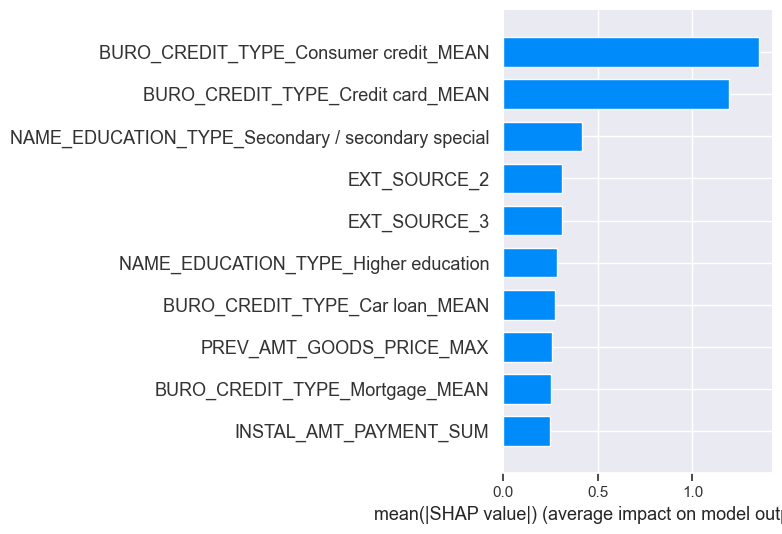

✔️ SHAP summary bar saved to artifacts/shap_summary_bar.png


In [50]:
# ⚠️ Explainer doit utiliser le modèle et les données transformées
shap_values_va = explainer(X_va_proc_df)


# ============================
# 3. Summary Plot (barplot)
# ============================

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_va,
    X_va_proc_df,
    plot_type="bar",
    max_display=10,
    show=True  # indispensable pour éviter l'affichage dans notebook
)
plt.tight_layout()

# ============================
# 4. Sauvegarde
# ============================

path = "artifacts/shap_summary_bar.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.close()

mlflow.log_artifact(path)

print("✔️ SHAP summary bar saved to", path)


In [46]:
#SHAP values sur X_va

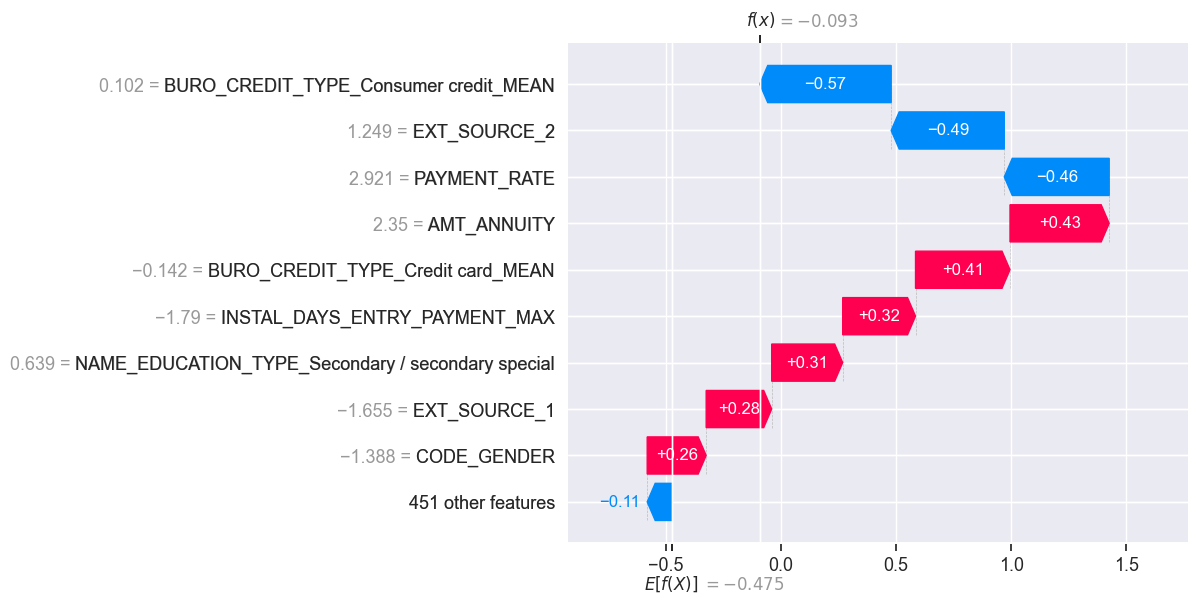

In [51]:
# exemple
i=0
plt.figure()
shap.plots.waterfall(
    shap_values_va[i],
    max_display=10,
    show=True
)
plt.tight_layout()
plt.savefig("artifacts/shap_scatter_client_0.png", dpi=150)
plt.close()
mlflow.log_artifact("artifacts/shap_scatter_client_0.png")



In [66]:
import joblib, json
# ============================================================
# sauvegarde du modèle + métadonnées
# ============================================================

os.makedirs("models", exist_ok=True)

# Sauvegarde du modèle entraîné
joblib.dump(final_model, "models/credit_risk_model.pkl")
mlflow.log_artifact("models/credit_risk_model.pkl")

# Sauvegarde des métadonnées : seuil, coût, features, version
metadata = {
    "threshold": float(best_t),
    "cost_fn": float(COST_FN),
    "cost_fp": float(COST_FP),
    "features": list(X.columns),
    "model_version": "logreg_weight_v1"
}

with open("models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

mlflow.log_artifact("models/metadata.json")
# Log MLflow du modèle pour usage ultérieur
mlflow.sklearn.log_model(final_model, name="sklearn_model")

print("\nModèle et métadonnées sauvegardés dans le dossier 'models/'")

mlflow.end_run()
print("Run MLflow terminé ✅")


2025/11/17 01:20:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Modèle et métadonnées sauvegardés dans le dossier 'models/'
Run MLflow terminé ✅


In [80]:
pip show evidently

Name: evidently
Version: 0.7.16
Summary: Open-source tools to analyze, monitor, and debug machine learning model in production.
Home-page: https://github.com/evidentlyai/evidently
Author: Emeli Dral
Author-email: emeli.dral@gmail.com
License: 
Location: /Users/frabe/.pyenv/versions/3.11.3/lib/python3.11/site-packages
Requires: certifi, cryptography, deprecation, dynaconf, fsspec, iterative-telemetry, litestar, nltk, numpy, pandas, plotly, pydantic, PyYAML, requests, rich, scikit-learn, scipy, statsmodels, typer, typing-inspect, ujson, urllib3, uuid6, uvicorn, watchdog
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [84]:
# =========================
# DATA Drift - Evidently 0.7.16
# =========================

import pandas as pd
from evidently import Report
from evidently import Dataset, DataDefinition
from evidently.descriptors import Sentiment, TextLength, Contains
from evidently.presets import TextEvals

# données
common_cols = [c for c in X.columns if c in X_test.columns]
ref_data = X[common_cols]
cur_data = X_test[common_cols]

report = Report([
    DataDriftPreset(method="psi")
],
include_tests="True")

# The .run() method remains the same
result = report.run(reference_data=ref_data, current_data=cur_data)



Path("artifacts").mkdir(exist_ok=True)
html_path = "artifacts/data_drift_report.html"

# The save_html method remains the same
result.save_html(html_path)

print(f"✔️ Rapport Evidently généré : {html_path}")

# Note: In version 0.7.x, the output will be a TestSuite result (Pass/Fail)
# rather than the full visual Report available in modern versions.

✔️ Rapport Evidently généré : artifacts/data_drift_report.html


# Optimisation métier

objectif métier = détecter un maximum de défauts sans perdre trop de précision.

Quand le modèle prédit si un client remboursera (0) ou fera défaut (1), il peut se tromper de deux façons :

| Type d’erreur         | Cas réel           | Prédiction du modèle | Signification                                   |
| --------------------- | ------------------ | -------------------- | ----------------------------------------------- |
| **Faux positif (FP)** | Bon client (0)     | Mauvais client (1)   | on rejette un bon client à tort                |
| **Faux négatif (FN)** | Mauvais client (1) | Bon client (0)       | on accepte un client qui ne remboursera pas |

Le coût métier de ces erreurs

- Si on refuse un bon client (FP) → on perd un peu de chiffre d’affaires

- Si on accepte un mauvais client (FN) → on perd beaucoup d’argent car il ne rembourse pas

Un faux négatif coûte plus cher qu’un faux positif.

On préfère repérer le plus possible de mauvais payeurs,
même si cela veut dire refuser à tort quelques bons clients.


1 faux négatif (FN) coûte 10× plus cher qu’un faux positif (FP).
En d’autres termes, on valorise la détection des défauts, quitte à avoir un peu plus de faux positifs.


In [ ]:
# objectif métier = détecter un maximum de défauts sans perdre trop de précision

| Élément                           | Signification                                                                                                              |
| --------------------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| **Seuil = 0.530**                 | le modèle doit classer un client comme “défaillant” s’il a **plus de 54 %** de probabilité estimée.                       |
| **Coût minimal = 2966**           | En appliquant ce seuil, on minimise le **coût métier global** (faux négatifs + faux positifs pondérés).                  |
| **COST_FN / COST_FP = 0.9 / 0.1** | on a décidé qu’un **faux négatif (défaut non détecté)** coûte 9× plus cher qu’un **faux positif (client refusé à tort)**. |


En d’autres termes

Si tu mets le seuil plus bas (< 0.54) → tu détectes plus de mauvais clients,
mais tu refuses plus de bons → ton coût augmente à cause des faux positifs.

Si tu mets le seuil plus haut (> 0.54) → tu acceptes plus de mauvais clients,
donc ton coût augmente à cause des faux négatifs.

Le 0.54 équilibre ces deux effets selon tes poids métier (0.9 / 0.1).

In [82]:
#!pip uninstall -y evidently
#!pip install evidently
!pip show evidently

Name: evidently
Version: 0.7.16
Summary: Open-source tools to analyze, monitor, and debug machine learning model in production.
Home-page: https://github.com/evidentlyai/evidently
Author: Emeli Dral
Author-email: emeli.dral@gmail.com
License: 
Location: /Users/frabe/.pyenv/versions/3.11.3/lib/python3.11/site-packages
Requires: certifi, cryptography, deprecation, dynaconf, fsspec, iterative-telemetry, litestar, nltk, numpy, pandas, plotly, pydantic, PyYAML, requests, rich, scikit-learn, scipy, statsmodels, typer, typing-inspect, ujson, urllib3, uuid6, uvicorn, watchdog
Required-by: 


après application du seuil métier optimal (≈ 0.54 ), on détecte 65 % des défauts (recall ) tout en gardant une précision correcte (≈ 19 %).


Étape 1 — Confirmer sur la Cross-Validation (CV)
le seuil est trouvé sur le split interne (validation), mais il faut s’assurer qu’il généralise bien :

Étape 2 — Appliquer le modèle final sur tout le jeu d’entraînement

Étape 3 — Prédire sur le jeu de test final